In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv("Netflix Dataset.csv")
sns.set_theme(style="whitegrid")

#DATA CLEANING BY REMOVING DUPLICATE DATA

In [51]:
df.drop_duplicates(inplace=True)

#FILL MISSING VALUES

In [52]:
df["Director"] = df["Director"].fillna("Unknown")
df["Country"] = df["Country"].fillna("Unknown")
df["Rating"] = df["Rating"].fillna("Not Rated")

#CONVERT DURATION INTO MINUTES(MOVIES ONLY)

In [39]:
movies = df[df["Category"] == "Movie"].copy()
movies["Minutes"] = (
    movies["Duration"]
    .str.extract(r'(\d+)')
    .astype(float)
)

#1 Find the total number of Movies and TV Shows available on Netflix

In [41]:
category = df["Category"].value_counts()

print(category)

Category
Movie      5377
TV Show    2410
Name: count, dtype: int64


#2 Identify the percentage of Movies vs TV Shows.

In [42]:
category_percentage = (
    df["Category"].value_counts(normalize=True)* 100
)
print(category_percentage)

Category
Movie      69.050982
TV Show    30.949018
Name: proportion, dtype: float64


#3	Find the top 10 countries producing Netflix content.	Content Count by Country

In [43]:
top_country = ( df["Country"].value_counts().head(10))
print(top_country)

Country
United States     2555
India              923
Unknown            507
United Kingdom     397
Japan              226
South Korea        183
Canada             177
Spain              134
France             115
Egypt              101
Name: count, dtype: int64


#4 Determine which director has directed the highest number of titles.

In [20]:
top_director = df["Director"].value_counts().head(1)
print(top_director)

Director
Unknown    2388
Name: count, dtype: int64


#5	Find the most common content rating

In [21]:
rating= (df["Rating"].value_counts().head(1))
print(rating)

Rating
TV-MA    2863
Name: count, dtype: int64


#6 Analyze content released over the years.	Titles Released per Year

In [53]:
df["Release_Date"] = df["Release_Date"].str.strip()

df["Release_Date"] = pd.to_datetime(
    df["Release_Date"],
    format="%B %d, %Y"
)

release = df["Release_Date"].dt.year.value_counts().sort_index()

print(release)

Release_Date
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      25
2015.0      88
2016.0     443
2017.0    1225
2018.0    1685
2019.0    2153
2020.0    2009
2021.0     117
Name: count, dtype: int64


#7 Identify the year with the highest number of releases.

In [54]:
release = df["Release_Date"].value_counts()
print(release.head(1))

Release_Date
2020-01-01    119
Name: count, dtype: int64


#8 Find the longest movie available on Netflix.

In [57]:
movies = df[df["Category"] == "Movie"].copy()

movies["Minutes"] = (
    movies["Duration"]
    .str.extract(r'(\d+)')
    .astype(float)
)

longest_movie = movies.loc[movies["Minutes"].idxmax()]

print(longest_movie[["Title", "Minutes"]])

Title      Black Mirror: Bandersnatch
Minutes                         312.0
Name: 957, dtype: object


#9	Calculate the average movie duration.

In [58]:
average_duration = movies["Minutes"].mean()
print(average_duration)

99.30797842663195


#10	Find the most frequently appearing actor

In [59]:
top_actor = (df["Cast"].str.split(", ").explode().value_counts().head(1))

print(top_actor)

Cast
Anupam Kher    42
Name: count, dtype: int64


#11	Analyze the distribution of content ratings by category.

In [60]:
rating_category = pd.crosstab(df["Category"], df["Rating"])

print(rating_category)

Rating     G  NC-17  NR  Not Rated   PG  PG-13    R  TV-14  TV-G  TV-MA  \
Category                                                                  
Movie     39      3  79          5  247    386  663   1272   111   1845   
TV Show    0      0   5          2    0      0    2    659    83   1018   

Rating    TV-PG  TV-Y  TV-Y7  TV-Y7-FV  UR  
Category                                    
Movie       505   117     95         5   5  
TV Show     301   163    176         1   0  


#12	Find the countries producing both Movies and TV Shows.

In [61]:
country_category = pd.crosstab(df["Country"], df["Category"])

both = country_category[
    (country_category["Movie"] > 0) &
    (country_category["TV Show"] > 0)
]

print(both)

Category                                  Movie  TV Show
Country                                                 
Argentina                                    34       16
Argentina, Spain                              7        1
Australia                                    37       46
Australia, Canada                             1        1
Australia, United States                      7        3
...                                         ...      ...
United States, Russia                         2        1
United States, Sweden                         2        1
United States, United Kingdom                30        7
United States, United Kingdom, Australia      3        1
Unknown                                     230      277

[93 rows x 2 columns]


#13	Determine which month has the highest number of releases.

In [64]:
df["Release_Date"] = pd.to_datetime(df["Release_Date"])
month = df["Release_Date"].dt.month_name().value_counts()
print(month.head(1))

Release_Date
December    833
Name: count, dtype: int64


#14	Find the percentage of missing values in each column.

In [66]:
missing = (df.isnull().sum() / len(df)) * 100
print(missing)

Show_Id         0.000000
Category        0.000000
Title           0.000000
Director        0.000000
Cast            9.220496
Country         0.000000
Release_Date    0.128419
Rating          0.000000
Duration        0.000000
Type            0.000000
Description     0.000000
dtype: float64


#15	Analyze the distribution of content types.

In [67]:
content_type = df["Category"].value_counts()

print(content_type)

Category
Movie      5377
TV Show    2410
Name: count, dtype: int64


#16	Find the top 15 directors based on the number of titles released.

In [68]:
top_directors = (df["Director"].value_counts().head(15))
print(top_directors)

Director
Unknown                   2388
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Jay Chapman                 12
Steven Spielberg            10
David Dhawan                 9
Kunle Afolayan               8
Hakan Algül                  8
Ryan Polito                  8
Shannon Hartman              8
Johnnie To                   8
Name: count, dtype: int64


#17	Determine the most popular content ratings in each country.

In [69]:
country_rating = (
    df.groupby("Country")["Rating"]
    .agg(lambda x: x.value_counts().index[0])
)

print(country_rating)

Country
Argentina                                              TV-MA
Argentina, Brazil, France, Poland, Germany, Denmark    TV-14
Argentina, Chile                                       TV-14
Argentina, Chile, Peru                                 TV-MA
Argentina, France                                      TV-MA
                                                       ...  
Venezuela                                              TV-14
Venezuela, Colombia                                       NR
Vietnam                                                TV-14
West Germany                                           TV-MA
Zimbabwe                                                TV-G
Name: Rating, Length: 682, dtype: str


#18	Compare Movie and TV Show releases over time.

In [70]:
trend = pd.crosstab(
    df["Release_Date"],
    df["Category"]
)

print(trend)

Category      Movie  TV Show
Release_Date                
2008-01-01        1        0
2008-02-04        0        1
2009-05-05        1        0
2009-11-18        1        0
2010-11-01        1        0
...             ...      ...
2021-01-12        2        1
2021-01-13        1        1
2021-01-14        2        0
2021-01-15        9        6
2021-01-16        3        0

[1512 rows x 2 columns]


#19	Identify the shortest movie available.

In [71]:
shortest_movie = movies.loc[movies["Minutes"].idxmin()]
print(shortest_movie[["Title", "Minutes"]])

Title      Silent
Minutes       3.0
Name: 5606, dtype: object


#20 Find the countries with the highest diversity of ratings

In [72]:
rating_diversity = (
    df.groupby("Country")["Rating"]
    .nunique()
    .sort_values(ascending=False)
)

print(rating_diversity)

Country
United States                                                           15
Canada                                                                  13
India                                                                   12
Australia                                                               11
Unknown                                                                 11
                                                                        ..
United States, United Kingdom, Spain, South Korea                        1
Australia, United Kingdom, United States, New Zealand, Italy, France     1
United States, Taiwan                                                    1
Argentina, United States, Mexico                                         1
Argentina, United States                                                 1
Name: Rating, Length: 682, dtype: int64


#21 Analyze title length (number of characters).

In [76]:
df["Title_Length"] = df["Title"].str.len()
print(df[["Title","Title_Length"]])
average_length = df["Title_Length"].mean()
print("Average Title Length:", average_length)

                                        Title  Title_Length
0                                          3%             2
1                                       07:19             5
2                                       23:59             5
3                                           9             1
4                                          21             2
...                                       ...           ...
7784                                     Zozo             4
7785                                   Zubaan             6
7786                        Zulu Man in Japan            17
7787                    Zumbo's Just Desserts            21
7788  ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS            39

[7787 rows x 2 columns]
Average Title Length: 17.63066649544112


#22 Find the most common words used in Netflix titles.

In [77]:
words = (
    df["Title"]
    .str.lower()
    .str.split()
    .explode()
)

common_words = words.value_counts().head(10)

print(common_words)

Title
the     1928
of       609
a        306
in       240
and      199
to       171
&        153
love     134
my       127
2         92
Name: count, dtype: int64


#23 Analyze description length for Movies vs TV Shows.

In [79]:
df["Desc_Length"] = df["Description"].str.len()
description = (
    df.groupby("Category")["Desc_Length"]
    .mean()
)

print(description)

Category
Movie      143.452297
TV Show    142.315353
Name: Desc_Length, dtype: float64


#24 Find duplicate titles in the dataset.

In [80]:
duplicate_titles = df[df.duplicated("Title")]
print(duplicate_titles)

Empty DataFrame
Columns: [Show_Id, Category, Title, Director, Cast, Country, Release_Date, Rating, Duration, Type, Description, Title_Length, Desc_Length]
Index: []


#25 Identify directors who have directed both Movies and TV Shows.

In [81]:
group = ( df.groupby(["Director", "Category"]).size().unstack(fill_value=0))

both = group[
    (group["Movie"] > 0) &
    (group["TV Show"] > 0)
]

print(both)

Category                           Movie  TV Show
Director                                         
Alessandro Angulo                      1        1
Anurag Basu                            4        1
BB Sasore                              1        1
Cosima Spender                         2        1
Dan Forrer                             1        1
Daniel Kontur                          1        1
David Ayer                             2        1
Eli Roth                               2        1
Estela Renner                          1        1
Jalil Lespert                          2        1
Jay Chandrasekhar                      1        1
Jerry Seinfeld                         1        1
Justin Webster                         1        1
Kobun Shizuno, Hiroyuki Seshita        2        1
Kyran Kelly                            1        1
Manolo Caro                            1        1
Marcus Raboy                          15        1
Mark Tonderai                          1        1


#26 Find the trend of family-friendly content over the years.

In [82]:
family = df[
    df["Rating"].isin(["G", "PG", "TV-G", "TV-Y", "TV-Y7"])
]

trend = family["Release_Date"].value_counts().sort_index()

print(trend)

Release_Date
2012-02-21    1
2013-12-12    1
2013-12-29    1
2014-02-16    1
2014-06-15    1
             ..
2021-01-05    1
2021-01-07    1
2021-01-08    2
2021-01-10    2
2021-01-15    6
Name: count, Length: 498, dtype: int64


#27 Identify the countries contributing to mature-rated content.

In [83]:
mature = df[
    df["Rating"].isin(["TV-MA", "R"])
]

country = mature["Country"].value_counts()

print(country)

Country
United States                                                   1244
India                                                            230
United Kingdom                                                   199
Unknown                                                          161
Spain                                                            111
                                                                ... 
Romania, Bulgaria, Hungary                                         1
United Kingdom, Ukraine, United States                             1
Croatia, Slovenia, Serbia, Montenegro                              1
United Arab Emirates, Jordan                                       1
Sweden, Czech Republic, United Kingdom, Denmark, Netherlands       1
Name: count, Length: 399, dtype: int64


#28 Build a dashboard showing all major KPIs.

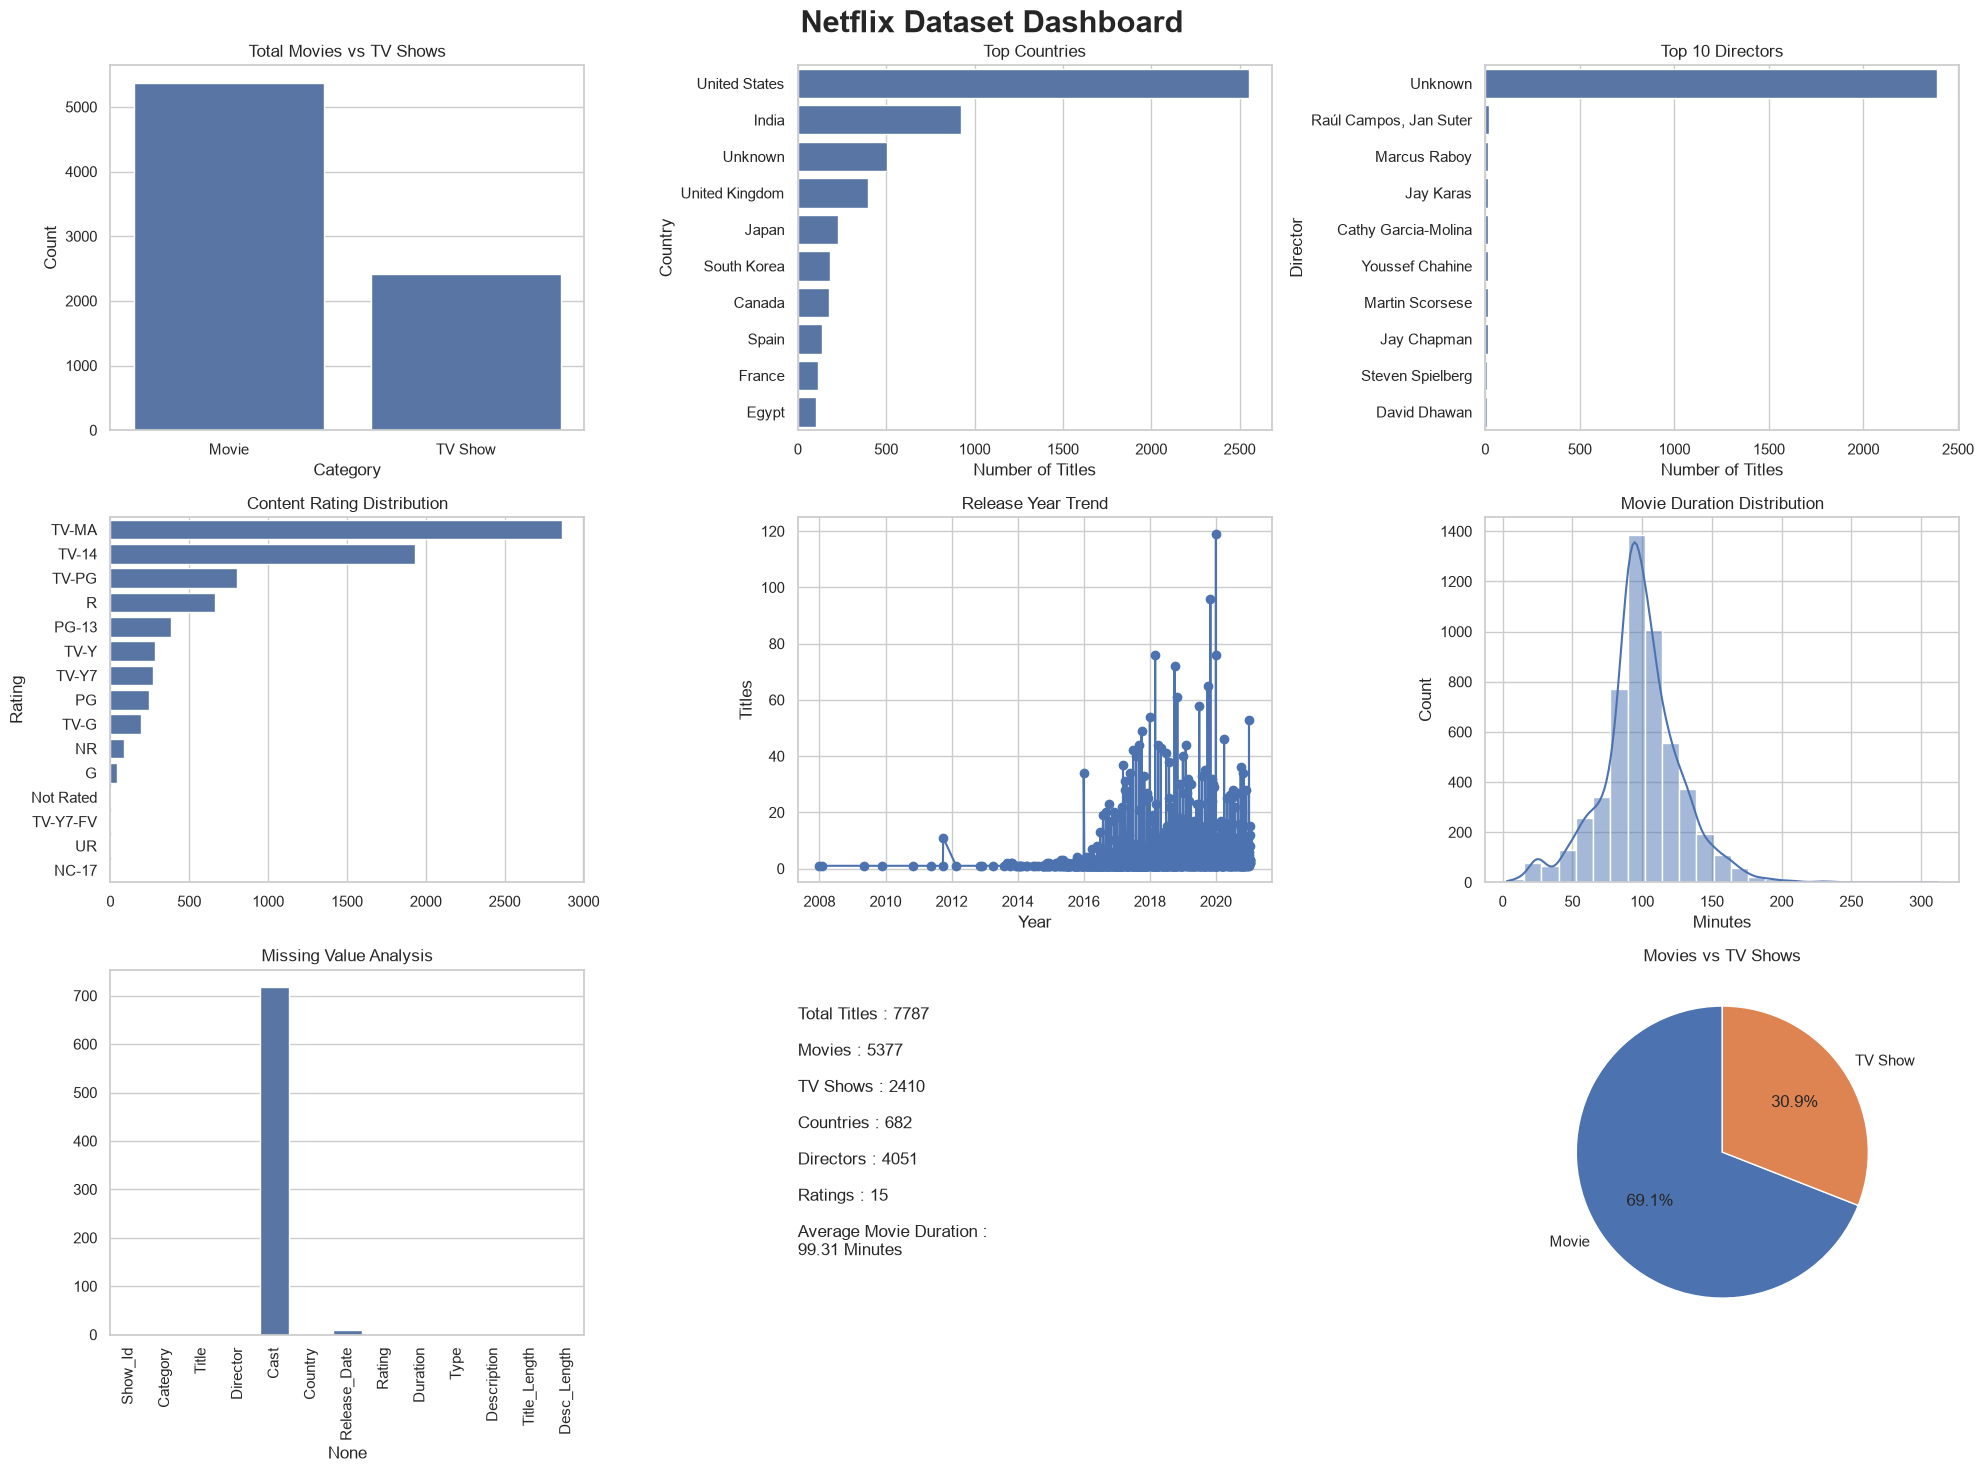

In [90]:
fig, ax = plt.subplots(3,3, figsize=(20,15))

#------------------------------
#1. TOTAL MOVIES AND Tv SHOWS
#------------------------------
category = df["Category"].value_counts()

sns.barplot(
    x=category.index,
    y=category.values,
    ax= ax[0,0]
)

ax[0,0].set_title("Total Movies vs TV Shows")
ax[0,0].set_xlabel("Category")
ax[0,0].set_ylabel("Count")

#-----------------
#2. TOP COUNTRIES
#------------------
top_country= df["Country"].value_counts().head(10)

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    ax= ax[0,1]
)

ax[0,1].set_title("Top Countries")
ax[0,1].set_xlabel("Number of Titles")
ax[0,1].set_ylabel("Country")

# --------------------------------------
# 3. TOP DIRECTORS
# --------------------------------------
top_director = df ["Director"].value_counts().head(10)
sns.barplot(
    x=top_director.values,
    y=top_director.index,
    ax=ax [0,2]
)

ax[0,2].set_title("Top 10 Directors")
ax[0,2].set_xlabel("Number of Titles")
ax[0,2].set_ylabel("Director")

# -------------------------------------------------------
# 4. Content Rating Distribution
# -------------------------------------------------------
rating = df["Rating"].value_counts()

sns.barplot(
    x=rating.values,
    y=rating.index,
    ax=ax[1,0]
)

ax[1,0].set_title("Content Rating Distribution")

# -------------------------------------------------------
# 5. Release Year Trend
# -------------------------------------------------------
release = df["Release_Date"].value_counts().sort_index()

ax[1,1].plot(
    release.index,
    release.values,
    marker="o"
)

ax[1,1].set_title("Release Year Trend")
ax[1,1].set_xlabel("Year")
ax[1,1].set_ylabel("Titles")

# -------------------------------------------------------
# 6. Movie Duration Distribution
# -------------------------------------------------------
sns.histplot(
    movies["Minutes"],
    bins=25,
    kde=True,
    ax=ax[1,2]
)

ax[1,2].set_title("Movie Duration Distribution")

# -------------------------------------------------------
# 7. Missing Value Analysis
# -------------------------------------------------------
missing = df.isnull().sum()

sns.barplot(
    x=missing.index,
    y=missing.values,
    ax=ax[2,0]
)

ax[2,0].tick_params(axis='x', rotation=90)
ax[2,0].set_title("Missing Value Analysis")

# -------------------------------------------------------
# 8. Dataset Summary
# -------------------------------------------------------
ax[2,1].axis("off")

summary = f"""
Total Titles : {len(df)}

Movies : {len(df[df['Category']=='Movie'])}

TV Shows : {len(df[df['Category']=='TV Show'])}

Countries : {df['Country'].nunique()}

Directors : {df['Director'].nunique()}

Ratings : {df['Rating'].nunique()}

Average Movie Duration :
{round(np.mean(movies['Minutes']),2)} Minutes
"""

ax[2,1].text(
    0,
    0.95,
    summary,
    fontsize=12,
    verticalalignment="top"
)

# -------------------------------------------------------
# 9. Movies vs TV Shows Pie Chart
# -------------------------------------------------------
ax[2,2].pie(
    category.values,
    labels=category.index,
    autopct="%1.1f%%",
    startangle=90
)

ax[2,2].set_title("Movies vs TV Shows")

plt.suptitle(
    "Netflix Dataset Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

#29 Perform Exploratory Data Analysis (EDA).

In [85]:
print(df.info())
print(df.describe())
print(df.shape)
print(df.columns)
print(df.head(4))
print(df.tail(4))
print(df.isnull().sum())

#1. Movie Duration Statistics
print("Mean:", movies["Minutes"].mean())
print("Minimum:", movies["Minutes"].min())
print("Maximum:", movies["Minutes"].max())
print("Standard Deviation:", movies["Minutes"].std())

#2. Title Length Statistics
df["Title_Length"] = df["Title"].str.len()

print("Mean:", df["Title_Length"].mean())
print("Minimum:", df["Title_Length"].min())
print("Maximum:", df["Title_Length"].max())
print("Standard Deviation:", df["Title_Length"].std())

print(df["Category"].value_counts())

print(df["Rating"].value_counts())

<class 'pandas.DataFrame'>
Index: 7787 entries, 0 to 7788
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Show_Id       7787 non-null   str           
 1   Category      7787 non-null   str           
 2   Title         7787 non-null   str           
 3   Director      7787 non-null   str           
 4   Cast          7069 non-null   str           
 5   Country       7787 non-null   str           
 6   Release_Date  7777 non-null   datetime64[us]
 7   Rating        7787 non-null   str           
 8   Duration      7787 non-null   str           
 9   Type          7787 non-null   str           
 10  Description   7787 non-null   str           
 11  Title_Length  7787 non-null   int64         
 12  Desc_Length   7787 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(10)
memory usage: 851.7 KB
None
                     Release_Date  Title_Length  Desc_Length
count                    

#30 Generate actionable business insights for Netflix content strategy.

In [88]:
print('''*Netflix has more Movies than TV Shows, so increasing high-quality TV Shows could attract more long-term viewers.
\n*Countries like the USA and India contribute the most content, indicating strong production hubs.
\n*Certain directors release content more frequently, so Netflix could strengthen partnerships with these creators.
\n*If TV-MA is the most common rating, Netflix could consider expanding family-friendly content to reach younger audiences.
\n*If releases have increased in recent years, it suggests Netflix is growing its content library.
\n*Countries with a wider variety of content ratings may appeal to a broader audience, so investing in diverse content could improve global engagement.
''')

*Netflix has more Movies than TV Shows, so increasing high-quality TV Shows could attract more long-term viewers.

*Countries like the USA and India contribute the most content, indicating strong production hubs.

*Certain directors release content more frequently, so Netflix could strengthen partnerships with these creators.

*If TV-MA is the most common rating, Netflix could consider expanding family-friendly content to reach younger audiences.

*If releases have increased in recent years, it suggests Netflix is growing its content library.

*Countries with a wider variety of content ratings may appeal to a broader audience, so investing in diverse content could improve global engagement.

